<a href="https://colab.research.google.com/github/LucaMacedo/Data_Analysis/blob/main/turing_test_ki_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Turing-Test Auswertung

Teil der Auswertung:
- Es werden nur komplett ausgefüllte Fragebögen berücksichtigt.
- Teilnehmer, die den Bogen nur teilweise oder den Datenschutz abgelehnt haben, sind nicht Teil der Auswertung.
- Es werden nur Teilnehmer berücksichtigt, die sich selbst als technikaffin eingeschätzt haben und einen technischen bzw. informationstechnischen Studiengang belegen oder in diesem Bereich arbeiten.

## Import der Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_1samp, norm, wilcoxon, shapiro
from scipy import stats
import math

## Daten laden und filtern

In [ ]:
# Datei laden
df = pd.read_excel("data_turingtestki_2026-02-08_09-33.xlsx")

# Erste Zeile mit Beschreibungen entfernen
df = df.iloc[1:].copy()

# Nur vollständig abgeschlossene Interviews und technikaffine Personen
df = df[(df["STATUS"] == "complete") & (df["TT02"] == 1) & (df["TT15_01"] != "Test Melisa")]
# Person-ID festlegen
df["Person_ID"] = df["CASE"].astype(int)


## Pro Teilnehmer prüfen, ob die Antwort korrekt ist
## Hier handelt es sich um alle Personen, die sich selbst als technikaffin einschätzen.

In [ ]:
technisch = ["TT06", "TT01", "TT11", "TT12", "TT13"]  # JDBC, OOP, WI, DB, HTML
emotional = ["TT07", "TT08", "TT09", "TT10" ,"TT14"]                # Das Brot, Manche Tage, Sommer, Kant, Abschied


In [ ]:
# 1 = KI, 2 = Mensch
correct_answer = {
    "TT06": 1,
    "TT01": 1,
    "TT11": 1,
    "TT12": 1,
    "TT13": 1,
    "TT10": 2,
    "TT07": 2,
    "TT08": 2,
    "TT09": 2,
    "TT14": 2,
}


In [ ]:
for tt, correct in correct_answer.items():
    df[tt + "_Correct"] = (df[tt] == correct).astype(int)

In [ ]:
# Spaltennamen säubern
df.columns = df.columns.str.strip()

# Umbenennen
df = df.rename(columns={
    "TT03_01": "Alter",
    "TT04": "Berufskategorie",
    "TT05": "Geschlecht",
    "TT15_01": "Beschreibung",
    "TT16_01": "Studium"
})
# Werte ersetzen
df["Geschlecht"] = df["Geschlecht"].replace(
    {1: "m", 2: "w", 3: "d"}
)
df["Berufskategorie"] = df["Berufskategorie"].replace(
    {
    1: "IT / Technik",
    2: "Wirtschaft / Verwaltung",
    3: "Marketing / Kommunikation",
    4: "Bildung / Wissenschaft",
    5: "Gesundheit / Soziales",
    6: "Handwerk / Produktion",
    7: "Kunst / Medien / Design",
    8: "Recht / Öffentlicher Dienst",
    9: "Dienstleistung / Handel",
    10: "Selbstständig / Unternehmertum",
    11: "In Ausbildung / Studium",
    12: "Arbeitssuchend",
    13: "Sonstiges"
}
)
# Scores berechnen
df["Tech_Score"] = df[[tt + "_Correct" for tt in technisch]].mean(axis=1)
df["Emo_Score"] = df[[tt + "_Correct" for tt in emotional]].mean(axis=1)

# Analyse-DataFrame
scores = df[
    ["Person_ID", "Tech_Score", "Emo_Score",
     "Alter", "Berufskategorie", "Geschlecht",
     "Beschreibung", "Studium"]
].dropna()
scores

,Person_ID,Tech_Score,Emo_Score,Alter,Berufskategorie,Geschlecht,Beschreibung,Studium
5,102,0.6,0.8,28,Selbstständig / Unternehmertum,m,Ich bin Informatiker mit spezialisierung in Sp...,Informatik
6,103,0.6,0.4,22,IT / Technik,w,"Umgang mit Technik, neue Tools ausprobieren",Wirtschaftsinformatik
14,114,0.2,0.4,25,In Ausbildung / Studium,m,"Interesse + schnelle Auffassungsgabe auch in ""...",Advanced Business Management & Innovation (M.A.)
22,122,0.8,0.4,25,IT / Technik,w,Arbeite in der IT,Digital Business & Marketing Intelligence
23,123,0.6,0.8,24,Bildung / Wissenschaft,m,"Ich nutze viel technik, vergleich mit anderen",Informatik Master
26,126,0.8,0.6,23,IT / Technik,m,Arbeitserfahrung,Digital Business
27,127,0.2,0.8,26,In Ausbildung / Studium,m,Ich studiere Informatik.,Informatik
30,130,0.8,0.2,28,IT / Technik,m,Im Vergleich zu anderen Bereichen in meinem Le...,Energie- und Umwelttechnik
32,133,0.4,0.4,24,In Ausbildung / Studium,m,Erfahrung,Maschinenbau
35,136,0.4,0.8,24,IT / Technik,m,"Bastle gern an PCs, Servern, Maschinen, Autos,...",Maschinenbau Master


## Alle Studiengänge mit Personen, die sich technikaffin einschätzen

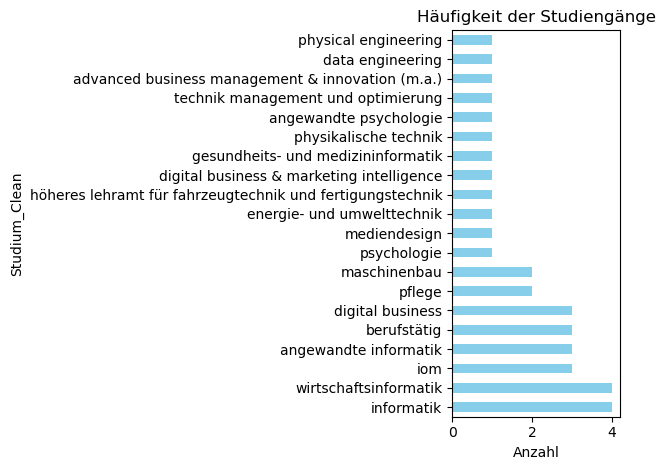

Studium_Clean
informatik                                                   4
wirtschaftsinformatik                                        4
iom                                                          3
angewandte informatik                                        3
berufstätig                                                  3
digital business                                             3
pflege                                                       2
maschinenbau                                                 2
psychologie                                                  1
mediendesign                                                 1
energie- und umwelttechnik                                   1
höheres lehramt für fahrzeugtechnik und fertigungstechnik    1
digital business & marketing intelligence                    1
gesundheits- und medizininformatik                           1
physikalische technik                                        1
angewandte psychologie                   

In [ ]:
# Daten bereinigen
# Alles in Kleinbuchstaben, Leerzeichen am Rand entfernen
scores['Studium_Clean'] = scores['Studium'].str.strip().str.lower()

# 2. (Optional) Manuelle Zusammenführung von Synonymen
# Hier kannst du ähnliche Begriffe gezielt bündeln
mapping = {
    'informatik master': 'informatik',
    'wirtschaftsinformatik plus': 'wirtschaftsinformatik',
    '"angewandte informatik"': 'angewandte informatik',
    'internet & online-marketing': 'iom',
    'internet und online marketing': 'iom',
    'maschinenbau master': 'maschinenbau',
    'angewandete informatik': 'angewandte informatik',
    'marketing': 'iom',
    'Marketing': 'iom'

}
scores['Studium_Clean'] = scores['Studium_Clean'].replace(mapping)

# Häufigkeiten zählen
studium = scores['Studium_Clean'].value_counts()
# Visualisieren
studium.plot(kind='barh', color='skyblue')
plt.title('Häufigkeit der Studiengänge')
plt.xlabel('Anzahl')
plt.tight_layout()
plt.show()
# Anzahl nach Studiengang
print(scores['Studium_Clean'].value_counts())

## Weitere Filterung der Daten, um nur technische Studiengänge, laut unserer Definition zu berücksichtigen

In [ ]:
scores = scores[(scores["Studium_Clean"] != "pflege") & (scores["Studium_Clean"] != "psychologie")]
#Passe Data Frame auch an
filtered_df = df[df["Person_ID"].isin(scores["Person_ID"])]
scores

,Person_ID,Tech_Score,Emo_Score,Alter,Berufskategorie,Geschlecht,Beschreibung,Studium,Studium_Clean
5,102,0.6,0.8,28,Selbstständig / Unternehmertum,m,Ich bin Informatiker mit spezialisierung in Sp...,Informatik,informatik
6,103,0.6,0.4,22,IT / Technik,w,"Umgang mit Technik, neue Tools ausprobieren",Wirtschaftsinformatik,wirtschaftsinformatik
14,114,0.2,0.4,25,In Ausbildung / Studium,m,"Interesse + schnelle Auffassungsgabe auch in ""...",Advanced Business Management & Innovation (M.A.),advanced business management & innovation (m.a.)
22,122,0.8,0.4,25,IT / Technik,w,Arbeite in der IT,Digital Business & Marketing Intelligence,digital business & marketing intelligence
23,123,0.6,0.8,24,Bildung / Wissenschaft,m,"Ich nutze viel technik, vergleich mit anderen",Informatik Master,informatik
26,126,0.8,0.6,23,IT / Technik,m,Arbeitserfahrung,Digital Business,digital business
27,127,0.2,0.8,26,In Ausbildung / Studium,m,Ich studiere Informatik.,Informatik,informatik
30,130,0.8,0.2,28,IT / Technik,m,Im Vergleich zu anderen Bereichen in meinem Le...,Energie- und Umwelttechnik,energie- und umwelttechnik
32,133,0.4,0.4,24,In Ausbildung / Studium,m,Erfahrung,Maschinenbau,maschinenbau
35,136,0.4,0.8,24,IT / Technik,m,"Bastle gern an PCs, Servern, Maschinen, Autos,...",Maschinenbau Master,maschinenbau


## Studiengänge nach Filterung

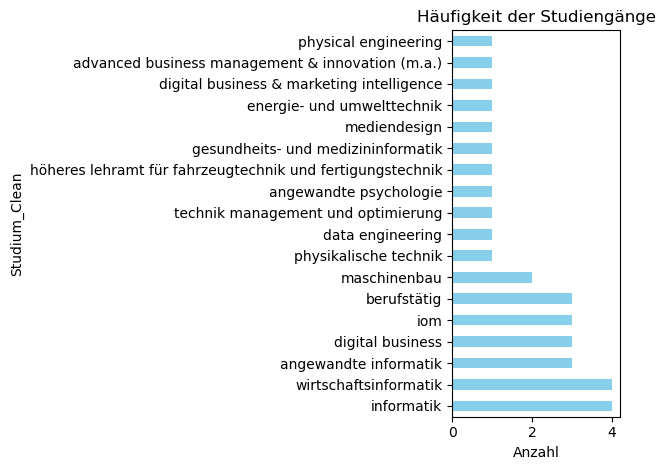

Studium_Clean
informatik                                                   4
wirtschaftsinformatik                                        4
angewandte informatik                                        3
digital business                                             3
iom                                                          3
berufstätig                                                  3
maschinenbau                                                 2
physikalische technik                                        1
data engineering                                             1
technik management und optimierung                           1
angewandte psychologie                                       1
höheres lehramt für fahrzeugtechnik und fertigungstechnik    1
gesundheits- und medizininformatik                           1
mediendesign                                                 1
energie- und umwelttechnik                                   1
digital business & marketing intelligence

In [ ]:
studium = scores['Studium_Clean'].value_counts()
# Visualisieren
studium.plot(kind='barh', color='skyblue')
plt.title('Häufigkeit der Studiengänge')
plt.xlabel('Anzahl')
plt.tight_layout()
plt.show()
# Anzahl nach Studiengang
print(scores['Studium_Clean'].value_counts())

## Antworten pro Teilnehmer

In [ ]:
answers = filtered_df[["TT06","TT01","TT07","TT08","TT09","TT10","TT11","TT12","TT13","TT14"]]
answers.value_counts()
counts = answers.apply(pd.Series.value_counts)
counts = counts.rename(columns={"TT06": "JDBC", "TT01": "OOP", "TT07": "Das Brot", "TT08": "Manche Tage", "TT09": "Sommer", "TT10": "Kant",
                      "TT11": "WI", "TT12": "DB", "TT13": "HTML", "TT14": "Abschied"}, index={1: 'KI-Text', 2: 'Menschlicher Text'})
counts = counts.iloc[:, [0,1,6,7,8,2,3,4,5,9]]# Reihenfolge ändern
counts

,JDBC,OOP,WI,DB,HTML,Das Brot,Manche Tage,Sommer,Kant,Abschied
KI-Text,18,16,16,23,20,19,21,9,13,15
Menschlicher Text,15,17,17,10,13,14,12,24,20,18


## Prozentuale Verteilung der Stimmen

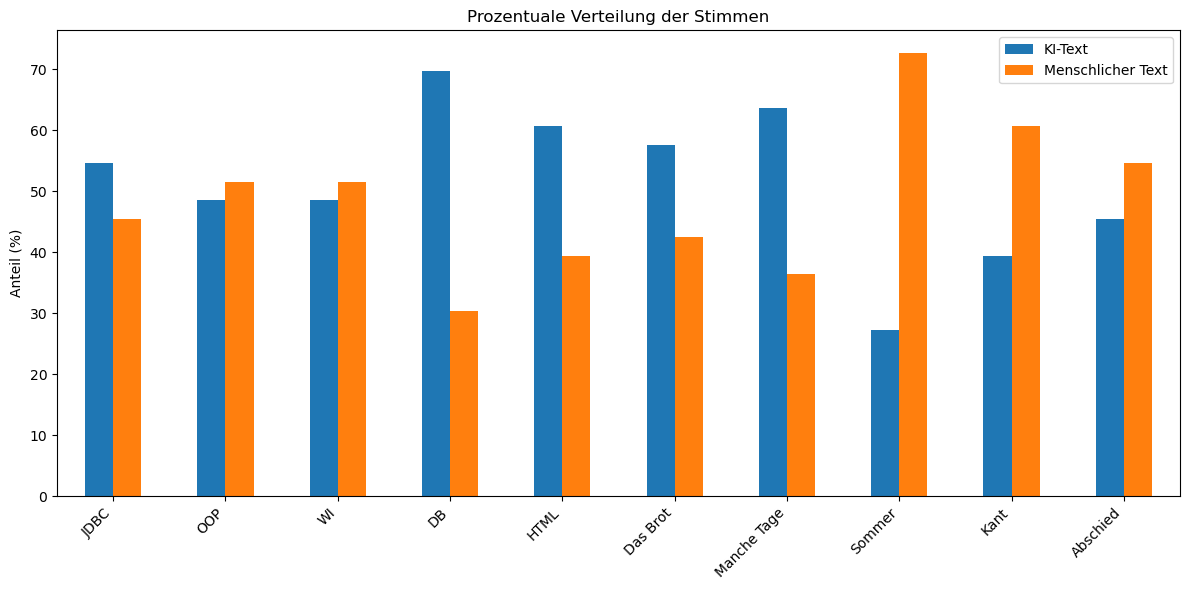

In [ ]:
counts_pct = counts.div(counts.sum(axis=0), axis=1) * 100

counts_pct.T.plot(
    kind="bar",
    figsize=(12,6)
)
plt.ylabel("Anteil (%)")
plt.title("Prozentuale Verteilung der Stimmen")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Geschlechterverteilung

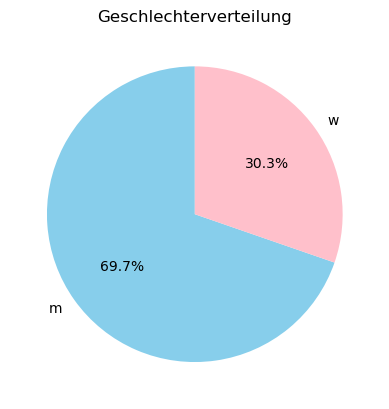

In [ ]:
# Geschlechter
# Häufigkeiten zählen
geschlechtsverteilung = scores['Geschlecht'].value_counts()
# Visualisieren
geschlechtsverteilung.plot(
    kind='pie',
    autopct='%1.1f%%',      # Zeigt Prozentzahlen im Diagramm an
    startangle=90,          # Dreht das Diagramm für bessere Optik
    colors=['skyblue', 'pink'],
    title='Geschlechterverteilung'
)
plt.ylabel('')
plt.show()

## Median nach Alter

In [ ]:
median_age = scores["Alter"].median()
print(f"Median nach Alter: {median_age}")

Median nach Alter: 24.0


## Berufskategorien

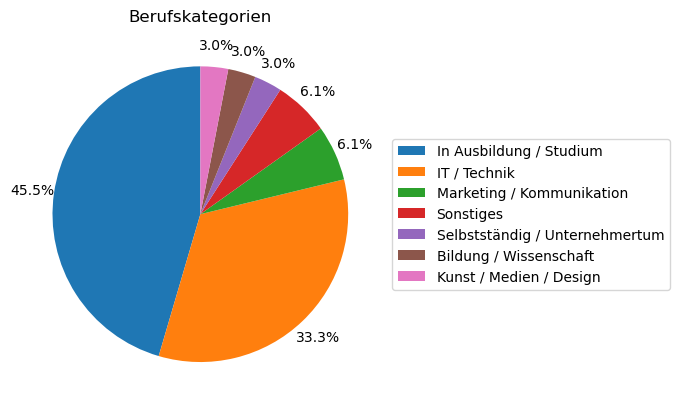

In [ ]:
# Häufigkeiten zählen
beruf = scores['Berufskategorie'].value_counts()

# Visualisieren
ax = beruf.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    labels=None,          # Labels am Kreis entfernen
    pctdistance=1.15,     # Prozentzahlen etwas nach außen rücken
    title='Berufskategorien'
)
plt.legend(beruf.index, loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.ylabel('')
plt.show()

## Test auf Normalverteilung

In [ ]:
print(shapiro(scores["Tech_Score"]))
print(shapiro(scores["Emo_Score"]))

ShapiroResult(statistic=np.float64(0.932250483049678), pvalue=np.float64(0.04057799264460415))
ShapiroResult(statistic=np.float64(0.8750751511371553), pvalue=np.float64(0.0012776583876142253))


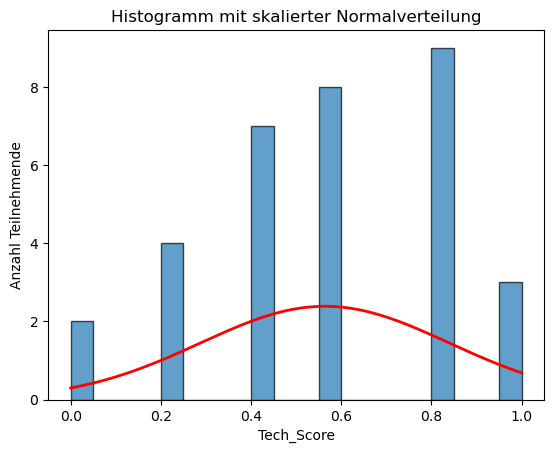

In [ ]:
data_tech = scores["Tech_Score"]

# Histogramm mit absoluten Häufigkeiten
counts, bins, _ = plt.hist(
    data_tech,
    bins=20,
    edgecolor="black",
    alpha=0.7
)

# Parameter
mu = data_tech.mean()
sigma = data_tech.std()

# x-Werte
x = np.linspace(bins.min(), bins.max(), 200)

# Skalierungsfaktor:
# n * binbreite
bin_width = bins[1] - bins[0]
y = norm.pdf(x, mu, sigma) * len(data_tech) * bin_width

# Glockenkurve
plt.plot(x, y, color="red", linewidth=2)

plt.xlabel("Tech_Score")
plt.ylabel("Anzahl Teilnehmende")
plt.title("Histogramm mit skalierter Normalverteilung")
plt.show()


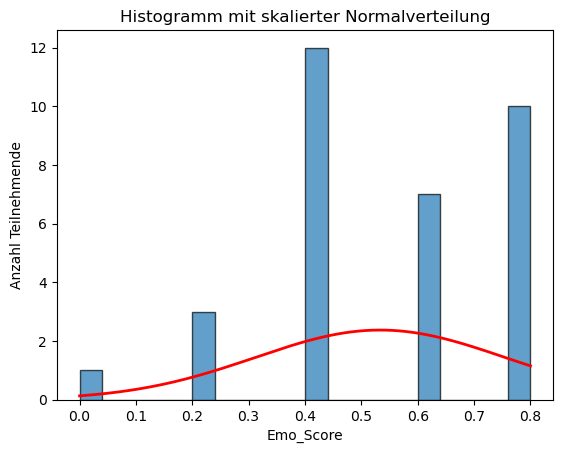

In [ ]:
data_emo = scores["Emo_Score"]

# Histogramm mit absoluten Häufigkeiten
counts, bins, _ = plt.hist(
    data_emo,
    bins=20,
    edgecolor="black",
    alpha=0.7
)

# Parameter
mu = data_emo.mean()
sigma = data_emo.std()

# x-Werte
x = np.linspace(bins.min(), bins.max(), 200)

# Skalierungsfaktor:
# n * binbreite
bin_width = bins[1] - bins[0]
y = norm.pdf(x, mu, sigma) * len(data_emo) * bin_width

# Glockenkurve
plt.plot(x, y, color="red", linewidth=2)

plt.xlabel("Emo_Score")
plt.ylabel("Anzahl Teilnehmende")
plt.title("Histogramm mit skalierter Normalverteilung")
plt.show()

## Werte sind nicht normalverteilt, weswegen der Wilcoxon-Test genommen wird.

In [ ]:
# Test durchführen (mit Normalverteilungs-Approximation für Z-Wert)
w, p = stats.wilcoxon(scores["Tech_Score"], scores["Emo_Score"])

# Z-Wert berechnen
z = stats.norm.ppf(p / 2) # Z-Wert aus dem p-Wert ableiten

# Effektstärke r
n = len(scores) * 2 # Gesamtzahl der Beobachtungen (N)
r = abs(z) / math.sqrt(n)
print(f"w: {w}, p: {p}")
print(f"Effektstärke r: {r}")

w: 154.5, p: 0.8286110963290226
Effektstärke r: 0.026647243463770523


## Deskriptiv statistische Werte der Punktzahlen in emotionalen und technischen Textfeldern

In [ ]:
scores[["Tech_Score", "Emo_Score"]].describe().round(2)

,Tech_Score,Emo_Score
count,33.00,33.00
mean,0.56,0.53
std,0.28,0.22
min,0.00,0.00
25%,0.40,0.40
50%,0.60,0.60
75%,0.80,0.80
max,1.00,0.80


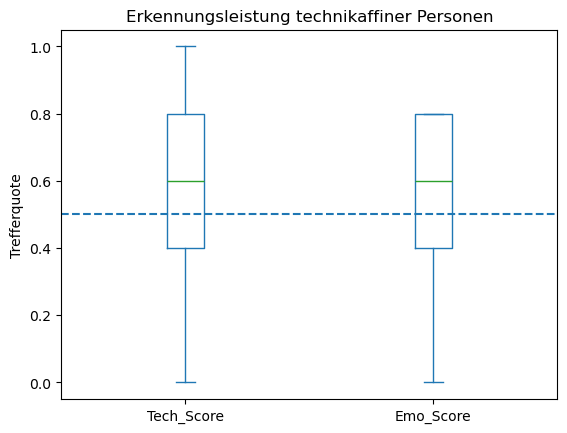

In [ ]:
scores[["Tech_Score", "Emo_Score"]].plot(kind="box")
plt.axhline(0.5, linestyle="--")
plt.ylabel("Trefferquote")
plt.title("Erkennungsleistung technikaffiner Personen")
plt.show()